# LANL Cyber1 Authentication — Exploratory Data Analysis

**Goal:** Support a **temporal graph neural network** for **host-level early warning** of lateral movement.

**Modeling stance:**
- **Hosts** are graph **nodes** (computers).
- **Authentication events** are **temporal directed edges** `src_computer → dst_computer` with **event attributes** (user, auth metadata); users are **not** separate nodes in the planned graph.
- This notebook validates **time structure**, **rolling host behavior** (6-hour history), **forecast horizon** (30 minutes), **decision cadence** (5 minutes), and **sparse host-level labels**.

**Data paths** (local): `./data/auth.txt.gz`, `./data/redteam.txt.gz`

## Configuration and imports

Set `SAMPLE_NROWS` for quick EDA; set `RUN_CHUNK_AGGREGATES = True` for full-file scans (slower, reads entire auth log in chunks).

In [1]:
import os
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Paths ---
DATA_DIR = "../project/data"
AUTH_PATH = f"{DATA_DIR}/auth.txt.gz"
REDTEAM_PATH = f"{DATA_DIR}/redteam.txt.gz"
FIGURES_DIR = "./figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# --- EDA mode ---
SAMPLE_NROWS = 2_000_000   # None = full read (not recommended for interactive auth EDA)
CHUNK_SIZE = 500_000
RUN_CHUNK_AGGREGATES = False  # set True for full-file aggregate statistics

# Forecast / rolling alignment (seconds)
DECISION_INTERVAL_SEC = 300    # 5 minutes
FORECAST_HORIZON_SEC = 30 * 60  # 30 minutes
ROLLING_WINDOW_SEC = 6 * 3600  # 6 hours

# Plot style
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

np.random.seed(42)

def savefig(name):
    path = os.path.join(FIGURES_DIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")

print("AUTH_PATH:", AUTH_PATH)
print("REDTEAM_PATH:", REDTEAM_PATH)
print("SAMPLE_NROWS:", SAMPLE_NROWS, "| RUN_CHUNK_AGGREGATES:", RUN_CHUNK_AGGREGATES)

AUTH_PATH: ../project/data/auth.txt.gz
REDTEAM_PATH: ../project/data/redteam.txt.gz
SAMPLE_NROWS: 2000000 | RUN_CHUNK_AGGREGATES: False


## Reusable helpers

- `load_auth_sample` — `nrows` for quick samples; `na_values` handles `"?"`.
- `load_redteam` — full red-team file (small).
- `attach_redteam_labels` — join on `(time, src_user, src_computer, dst_computer)` to `(time, user, src_computer, dst_computer)`.
- `aggregate_auth_chunks` — iterator / reducer pattern for scalable full-file aggregates.
- `build_host_features` — trailing-window rolling statistics on a sample for one host.

In [2]:
AUTH_COLS = [
    "time",
    "src_user",
    "dst_user",
    "src_computer",
    "dst_computer",
    "auth_type",
    "logon_type",
    "auth_orient",
    "success",
]
REDTEAM_COLS = ["time", "user", "src_computer", "dst_computer"]


# def load_auth_sample(path, nrows=None, chunksize=None, **kwargs):
#     # Read auth.txt.gz: nrows for head sample; chunksize for chunked iteration.
#     kw = dict(
#         compression="gzip",
#         header=None,
#         names=AUTH_COLS,
#         na_values=["?"],
#         low_memory=False,
#     )
#     kw.update(kwargs)
#     if chunksize:
#         return pd.read_csv(path, chunksize=chunksize, **kw)
#     return pd.read_csv(path, nrows=nrows, **kw)

# import pandas as pd
# import numpy as np

# AUTH_COLS = [
#     "time", "src_user", "dst_user", "src_computer", "dst_computer",
#     "auth_type", "logon_type", "auth_orient", "success",
# ]

def load_auth_sample(
    path,
    total_target_rows=2_000_000,
    chunk_size=500_000,
    per_chunk_frac=0.02,
    random_state=42,
):
    rng = np.random.default_rng(random_state)
    pieces = []

    reader = pd.read_csv(
        path,
        compression="gzip",
        header=None,
        names=AUTH_COLS,
        na_values=["?"],
        low_memory=False,
        chunksize=chunk_size,
    )

    for chunk in reader:
        n_take = min(len(chunk), max(1, int(len(chunk) * per_chunk_frac)))
        sampled_idx = rng.choice(len(chunk), size=n_take, replace=False)
        pieces.append(chunk.iloc[sampled_idx])

        current_rows = sum(len(x) for x in pieces)
        if current_rows >= total_target_rows:
            break

    out = pd.concat(pieces, ignore_index=True)
    out = out.sort_values("time").reset_index(drop=True)

    if len(out) > total_target_rows:
        out = out.sample(total_target_rows, random_state=random_state).sort_values("time").reset_index(drop=True)

    return out


def load_redteam(path):
    return pd.read_csv(
        path,
        compression="gzip",
        header=None,
        names=REDTEAM_COLS,
        na_values=["?"],
        low_memory=False,
    )


def attach_redteam_labels(auth_df, redteam_df, label_col="is_redteam"):
    # Join auth (time, src_user, src_computer, dst_computer) to redteam (user=src_user).
    a = auth_df.copy()
    rt = redteam_df.rename(columns={"user": "src_user"})
    keys = ["time", "src_user", "src_computer", "dst_computer"]
    m = a.merge(rt[keys].drop_duplicates(), on=keys, how="left", indicator=True)
    a[label_col] = m["_merge"] == "both"
    return a


def aggregate_auth_chunks(path, chunk_size, reducer_init, reduce_chunk, finalize):
    # Full scan: reducer_init -> state; reduce_chunk -> state; finalize.
    reader = load_auth_sample(path, chunksize=chunk_size)
    state = reducer_init()
    for chunk in reader:
        state = reduce_chunk(state, chunk)
    return finalize(state)


def build_host_features(
    auth_sample,
    host,
    window_sec=ROLLING_WINDOW_SEC,
    time_col="time",
):
    # Per-host timeline: rolling counts in trailing window (searchsorted).
    h = host
    sub = auth_sample[
        (auth_sample["src_computer"] == h) | (auth_sample["dst_computer"] == h)
    ].sort_values(time_col)
    if sub.empty:
        return pd.DataFrame()

    t = sub[time_col].to_numpy()
    succ = sub["success"].astype(str).str.lower().eq("success").to_numpy()

    rows = []
    w = float(window_sec)
    for i in range(len(sub)):
        ti = t[i]
        left = np.searchsorted(t, ti - w, side="left")
        right = i + 1
        sl = slice(left, right)
        ch = sub.iloc[sl]
        rows.append(
            {
                time_col: ti,
                "roll_auth": right - left,
                "roll_success": int(succ[sl].sum()),
                "roll_failure": int((~succ[sl]).sum()),
                "roll_out_deg": ch.loc[ch["src_computer"] == h, "dst_computer"].nunique(),
                "roll_in_deg": ch.loc[ch["dst_computer"] == h, "src_computer"].nunique(),
            }
        )
    return pd.DataFrame(rows)


def chunk_reduce_hour_day_counts():
    # Reducer factory: hourly and daily event counts + total rows.

    def init():
        return {
            "hour_counts": defaultdict(int),
            "day_counts": defaultdict(int),
            "nrows": 0,
        }

    def reduce(state, chunk):
        state["nrows"] += len(chunk)
        t = chunk["time"].astype(np.int64)
        hr = pd.Series(t // 3600)
        dy = pd.Series(t // 86400)
        for h, c in hr.value_counts().items():
            state["hour_counts"][int(h)] += int(c)
        for d, c in dy.value_counts().items():
            state["day_counts"][int(d)] += int(c)
        return state

    def finalize(state):
        return state

    return init, reduce, finalize


def chunk_reduce_missingness():
    # Fraction of missing values per column (NaN after read).

    def init():
        return {"missing_counts": None, "nrows": 0}

    def reduce(state, chunk):
        miss = chunk.isna().sum()
        state["nrows"] += len(chunk)
        if state["missing_counts"] is None:
            state["missing_counts"] = miss
        else:
            state["missing_counts"] = state["missing_counts"].add(miss, fill_value=0)
        return state

    def finalize(state):
        m = state["missing_counts"]
        frac = m / state["nrows"]
        return {"fraction_missing": frac, "nrows": state["nrows"]}

    return init, reduce, finalize


print("Helpers defined.")

Helpers defined.


## Load data

Quick sample of `auth` for most plots; full `redteam`; optional chunked aggregates when enabled.

In [3]:
print("Loading redteam...")
redteam = load_redteam(REDTEAM_PATH)
print("redteam shape:", redteam.shape)
print(redteam.head())
print()

print("Loading auth sample...")
auth = load_auth_sample(AUTH_PATH)
print("auth shape:", auth.shape)
print(auth.head())
print()

auth_labeled = attach_redteam_labels(auth, redteam)
n_rt = int(auth_labeled["is_redteam"].sum())
print("Red-team labeled rows in sample:", n_rt, "of", len(auth_labeled))

Loading redteam...
redteam shape: (749, 4)
     time        user src_computer dst_computer
0  150885   U620@DOM1       C17693        C1003
1  151036   U748@DOM1       C17693         C305
2  151648   U748@DOM1       C17693         C728
3  151993  U6115@DOM1       C17693        C1173
4  153792   U636@DOM1       C17693         C294

Loading auth sample...
auth shape: (2000000, 9)
   time              src_user              dst_user src_computer dst_computer  \
0     1  ANONYMOUS LOGON@C586  ANONYMOUS LOGON@C586        C1250         C586   
1     1              U78@DOM1              U78@DOM1        C1727        C1727   
2     2               U6@DOM1               U6@DOM1          C92           U6   
3     2           C1106$@DOM1             U45@C1106        C1106        C1106   
4     2           C3522$@DOM1          SYSTEM@C3522        C3522        C3522   

   auth_type logon_type auth_orient  success  
0       NTLM    Network       LogOn  Success  
1        NaN        NaN         TGS  Su

### Optional: chunked global aggregates (hour/day counts, missingness)

Enable `RUN_CHUNK_AGGREGATES = True` in the configuration cell to compute full-file hourly/daily totals and missingness without loading the entire file.

In [4]:
if RUN_CHUNK_AGGREGATES:
    init_f, red_f, fin_f = chunk_reduce_hour_day_counts()
    agg_hour_day = aggregate_auth_chunks(AUTH_PATH, CHUNK_SIZE, init_f, red_f, fin_f)
    print("Full scan row count:", agg_hour_day["nrows"])
    init_m, red_m, fin_m = chunk_reduce_missingness()
    miss_agg = aggregate_auth_chunks(AUTH_PATH, CHUNK_SIZE, init_m, red_m, fin_m)
    print("Missingness (fraction):")
    print(miss_agg["fraction_missing"])
else:
    agg_hour_day = None
    miss_agg = None
    print("Skipping full-file chunk aggregates (set RUN_CHUNK_AGGREGATES = True).")

Skipping full-file chunk aggregates (set RUN_CHUNK_AGGREGATES = True).


## 1. Event volume over time

Authentication events by **hour** and by **day** (enterprise rhythm, temporal structure).

Uses sample `auth` for plots unless chunked aggregates are available.

Saved: ./figures/01_auth_volume_by_hour.png


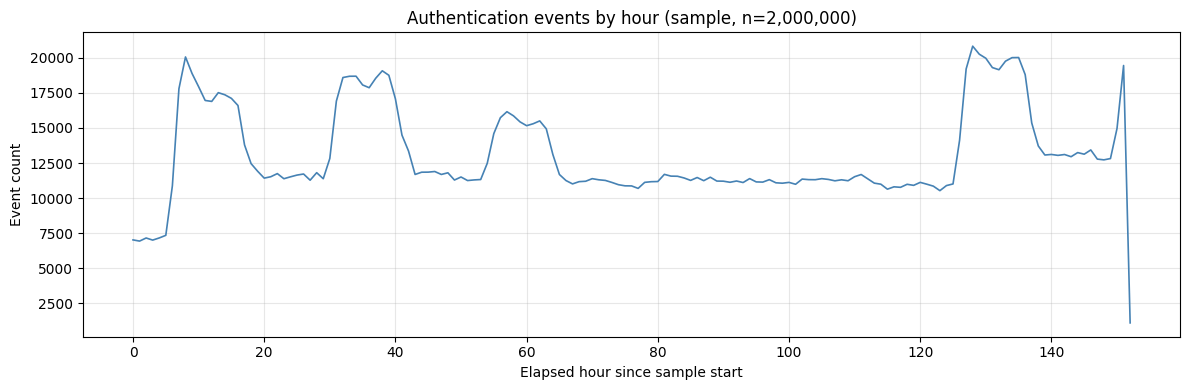

Saved: ./figures/01_auth_volume_by_day.png


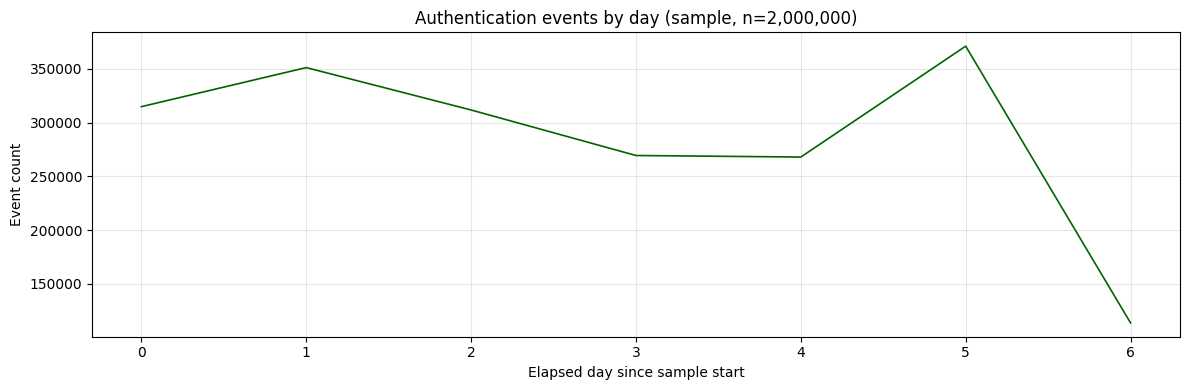

Hour bins: 153 | Day bins: 7
Total events in plot: 2000000
--- Section 1 summary: hourly/daily volume ---


In [5]:
auth = auth_labeled

# Anchor every time-axis plot to the start of the loaded sample. Using
# "elapsed since sample start" (instead of raw `time // 3600` indices) makes
# the x-axis directly interpretable: 0 = first event in the sample, and the
# numbers correspond to wall-clock hours / days that have elapsed.
t0 = int(auth["time"].min())
auth["elapsed_hour"] = (auth["time"] - t0) / 3600.0
auth["elapsed_day"] = (auth["time"] - t0) / 86400.0
auth["elapsed_hour_bin"] = np.floor(auth["elapsed_hour"]).astype(np.int64)
auth["elapsed_day_bin"] = np.floor(auth["elapsed_day"]).astype(np.int64)

if agg_hour_day:
    # The chunked aggregates are keyed by absolute hour/day indices over the
    # full file. Shift them so the x-axis is "elapsed since the first
    # observed hour/day" — the same interpretation as the sample path.
    hour_keys = sorted(agg_hour_day["hour_counts"].keys())
    h_min = hour_keys[0]
    hours = np.array([h - h_min for h in hour_keys], dtype=np.int64)
    h_counts = [agg_hour_day["hour_counts"][h] for h in hour_keys]
    day_keys = sorted(agg_hour_day["day_counts"].keys())
    d_min = day_keys[0]
    days = np.array([d - d_min for d in day_keys], dtype=np.int64)
    d_counts = [agg_hour_day["day_counts"][d] for d in day_keys]
    title_suffix = " (full file, chunked)"
else:
    hc = auth["elapsed_hour_bin"].value_counts().sort_index()
    hours, h_counts = hc.index.to_numpy(), hc.values
    dc = auth["elapsed_day_bin"].value_counts().sort_index()
    days, d_counts = dc.index.to_numpy(), dc.values
    title_suffix = f" (sample, n={len(auth):,})"

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hours, h_counts, color="steelblue", lw=1.2)
ax.set_title("Authentication events by hour" + title_suffix)
ax.set_xlabel("Elapsed hour since sample start")
ax.set_ylabel("Event count")
savefig("01_auth_volume_by_hour.png")
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(days, d_counts, color="darkgreen", lw=1.2)
ax.set_title("Authentication events by day" + title_suffix)
ax.set_xlabel("Elapsed day since sample start")
ax.set_ylabel("Event count")
savefig("01_auth_volume_by_day.png")
plt.show()

print("Hour bins:", len(hours), "| Day bins:", len(days))
print("Total events in plot:", int(np.sum(h_counts)))
print("--- Section 1 summary: hourly/daily volume ---")

## 2. Red-team activity over time

Overlay red-team **times** on overall volume; histograms of red-team events by hour and day.

Saved: ./figures/02_redteam_overlay_hour.png


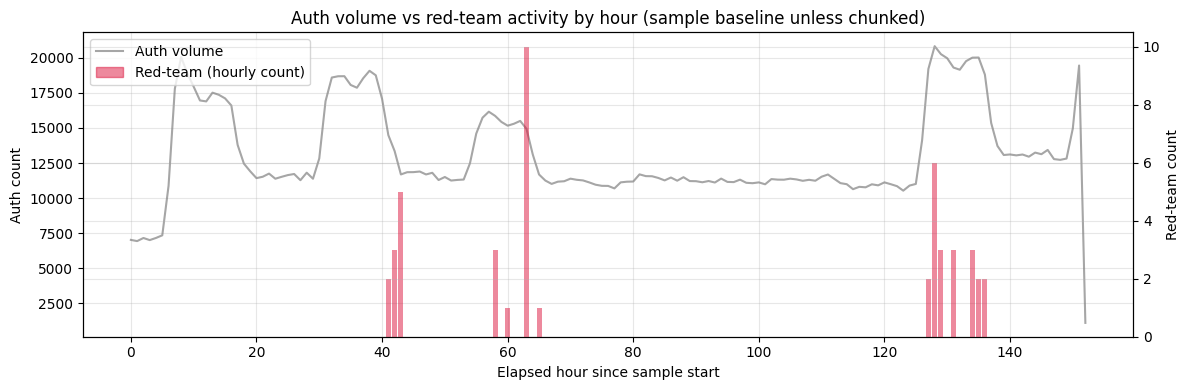

Saved: ./figures/02_redteam_hist_hour_day.png


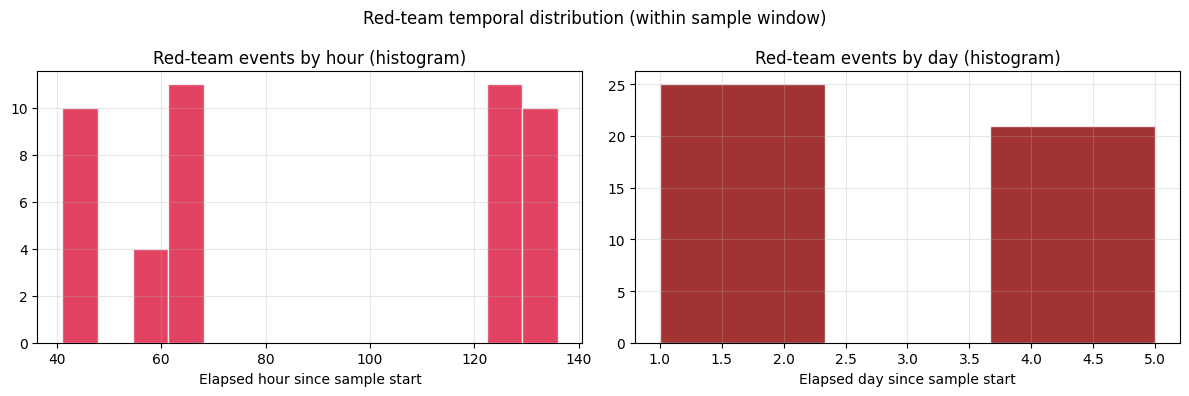

Red-team rows in sample window: 46 | Unique elapsed-hour bins: 14
--- Section 2 summary: red-team vs baseline ---


In [6]:
# Restrict red-team rows to the same time window as the loaded auth sample.
# Otherwise the overlay would mix red-team timestamps that fall completely
# outside the auth window, making the comparison meaningless.
t0 = int(auth["time"].min())
t_max = int(auth["time"].max())
rt = redteam[(redteam["time"] >= t0) & (redteam["time"] <= t_max)].copy()
rt["elapsed_hour"] = (rt["time"] - t0) / 3600.0
rt["elapsed_day"] = (rt["time"] - t0) / 86400.0
rt["elapsed_hour_bin"] = np.floor(rt["elapsed_hour"]).astype(np.int64)
rt["elapsed_day_bin"] = np.floor(rt["elapsed_day"]).astype(np.int64)

if agg_hour_day:
    # Same elapsed-shift convention as Section 1.
    hour_keys = sorted(agg_hour_day["hour_counts"].keys())
    h_min = hour_keys[0]
    ax_hours = np.array([h - h_min for h in hour_keys], dtype=np.int64)
    base_counts = np.array(
        [agg_hour_day["hour_counts"][h] for h in hour_keys], dtype=float
    )
else:
    hc = auth["elapsed_hour_bin"].value_counts().sort_index()
    ax_hours, base_counts = hc.index.to_numpy(), hc.values.astype(float)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ax_hours, base_counts, color="gray", alpha=0.7, label="Auth volume (hourly)")
ax2 = ax.twinx()
rh = rt["elapsed_hour_bin"].value_counts().sort_index()
ax2.bar(rh.index, rh.values, width=0.8, alpha=0.5, color="crimson", label="Red-team events (hourly)")
ax.set_xlabel("Elapsed hour since sample start")
ax.set_ylabel("Auth count")
ax2.set_ylabel("Red-team count")
ax.set_title("Auth volume vs red-team activity by hour (sample baseline unless chunked)")
lines = [ax.get_lines()[0], mpatches.Patch(color="crimson", alpha=0.5)]
labels = ["Auth volume", "Red-team (hourly count)"]
ax.legend(lines, labels, loc="upper left")
savefig("02_redteam_overlay_hour.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
n_hour_bins = max(rt["elapsed_hour_bin"].nunique(), 1)
n_day_bins = max(rt["elapsed_day_bin"].nunique(), 1)
axes[0].hist(rt["elapsed_hour_bin"], bins=min(100, n_hour_bins),
             color="crimson", alpha=0.8, edgecolor="white")
axes[0].set_title("Red-team events by hour (histogram)")
axes[0].set_xlabel("Elapsed hour since sample start")
axes[1].hist(rt["elapsed_day_bin"], bins=min(50, n_day_bins),
             color="darkred", alpha=0.8, edgecolor="white")
axes[1].set_title("Red-team events by day (histogram)")
axes[1].set_xlabel("Elapsed day since sample start")
plt.suptitle("Red-team temporal distribution (within sample window)")
savefig("02_redteam_hist_hour_day.png")
plt.show()

print("Red-team rows in sample window:", len(rt),
      "| Unique elapsed-hour bins:", rt["elapsed_hour_bin"].nunique())
print("--- Section 2 summary: red-team vs baseline ---")

## 3. Authentication outcome distribution

Success vs failure; temporal trend of failure share where feasible.

Outcome counts:
success
Success    1987805
Fail         12195
Name: count, dtype: int64
Saved: ./figures/03_outcome_bar.png


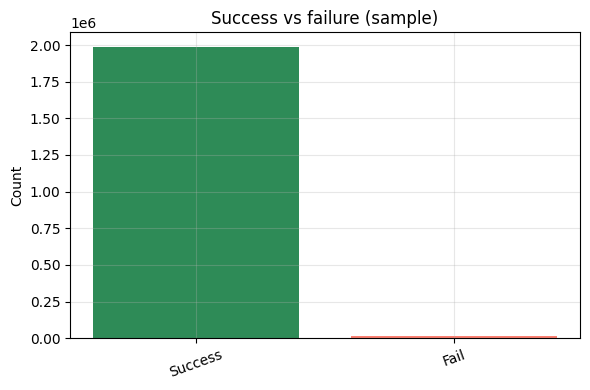

KeyError: 'hour'

In [7]:
outcome = auth["success"].astype(str)
vc = outcome.value_counts()
print("Outcome counts:")
print(vc)

fig, ax = plt.subplots(figsize=(6, 4))
cols = ["seagreen", "salmon", "gray", "orange", "purple"]
ax.bar(vc.index.astype(str), vc.values, color=cols[: len(vc)])
ax.set_title("Success vs failure (sample)")
ax.set_ylabel("Count")
plt.xticks(rotation=20)
savefig("03_outcome_bar.png")
plt.show()

auth["is_fail"] = ~auth["success"].astype(str).str.lower().eq("success")
hr_fail = auth.groupby("hour")["is_fail"].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hr_fail.index, hr_fail.values, color="darkred", label="Failure rate")
ax.set_xlabel("Hour index")
ax.set_ylabel("Fraction failure")
ax.set_title("Failure rate by hour (sample)")
ax.legend()
savefig("03_failure_rate_by_hour.png")
plt.show()

counts = auth.groupby(["hour", "is_fail"]).size().unstack(fill_value=0)
s_ct = counts.get(False, pd.Series(0, index=counts.index))
f_ct = counts.get(True, pd.Series(0, index=counts.index))
if s_ct.sum() + f_ct.sum() > 0:
    fig, ax = plt.subplots(figsize=(12, 4))
    hidx = counts.index
    ax.bar(hidx, s_ct, label="Success", color="seagreen")
    ax.bar(hidx, f_ct, bottom=s_ct, label="Failure", color="salmon")
    ax.set_xlabel("Hour index")
    ax.set_ylabel("Event count")
    ax.set_title("Success vs failure counts by hour (stacked, sample)")
    ax.legend()
    savefig("03_outcome_stacked_by_hour.png")
    plt.show()

print("Overall failure fraction:", float(auth["is_fail"].mean()))
print("Section 3 summary — outcome distribution and hourly failure trend plotted.")

## 4. Top authentication metadata categories

Bar plots for `auth_type`, `logon_type`, `auth_orient` (dominant vs rare events).

Saved: ./figures/04_auth_type.png


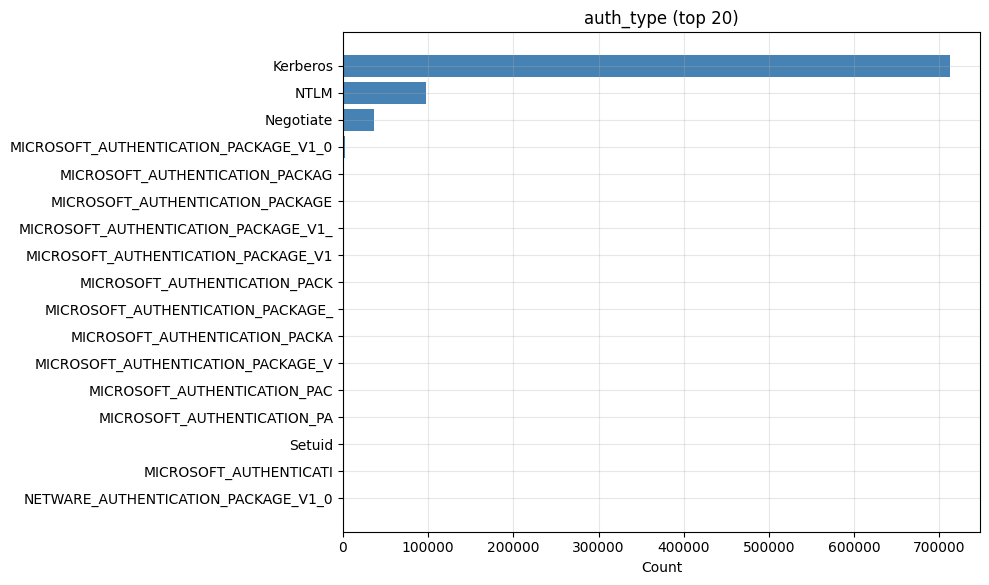

auth_type unique: 17 | top value: Kerberos
Saved: ./figures/04_logon_type.png


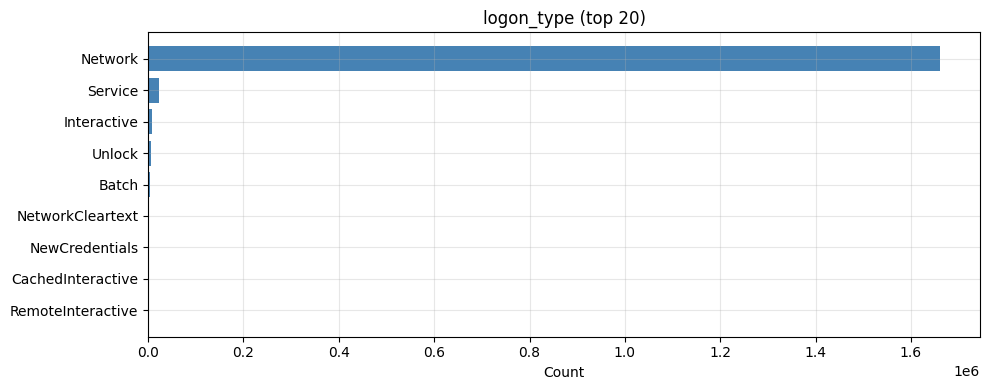

logon_type unique: 9 | top value: Network
Saved: ./figures/04_auth_orient.png


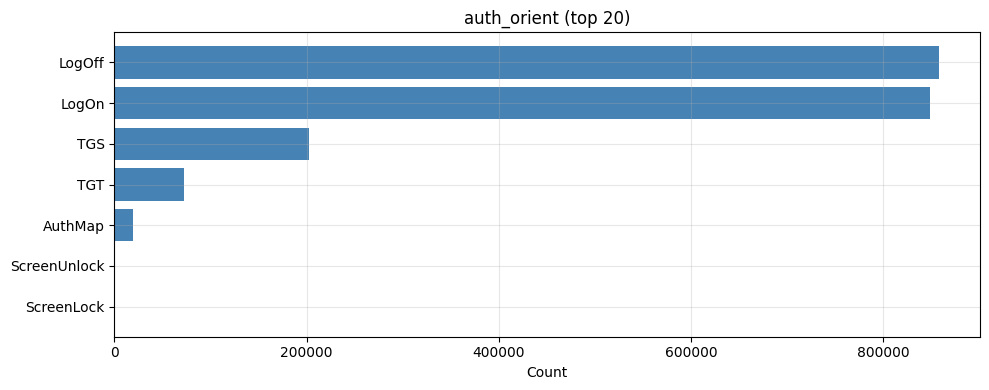

auth_orient unique: 7 | top value: LogOff
--- Section 4 summary: metadata category bars ---


In [8]:
def top_category_bar(series, title, fname, top_n=20):
    vc = series.astype(str).value_counts().head(top_n)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(vc))))
    ax.barh(vc.index[::-1], vc.values[::-1], color="steelblue")
    ax.set_title(title + f" (top {top_n})")
    ax.set_xlabel("Count")
    savefig(fname)
    plt.show()
    print(title, "unique:", series.nunique(), "| top value:", vc.index[0] if len(vc) else None)


top_category_bar(auth["auth_type"], "auth_type", "04_auth_type.png")
top_category_bar(auth["logon_type"], "logon_type", "04_logon_type.png")
top_category_bar(auth["auth_orient"], "auth_orient", "04_auth_orient.png")
print("--- Section 4 summary: metadata category bars ---")

## 5. Missingness / unknown values

Fraction of missing (NaN after treating `?` as NA) per column — sample and optional full scan.

Sample missing fraction by column:
time                0.000000
src_user            0.000000
dst_user            0.000000
src_computer        0.000000
dst_computer        0.000000
auth_type           0.575947
logon_type          0.147021
auth_orient         0.000000
success             0.000000
is_redteam          0.000000
elapsed_hour        0.000000
elapsed_day         0.000000
elapsed_hour_bin    0.000000
elapsed_day_bin     0.000000
is_fail             0.000000
dtype: float64
Saved: ./figures/05_missingness_sample.png


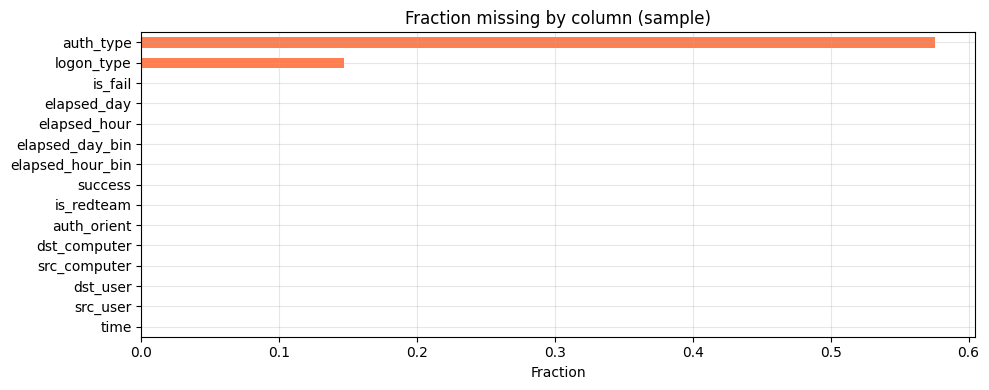

--- Section 5 summary: missingness ---


In [9]:
miss_s = auth.isna().mean()
print("Sample missing fraction by column:")
print(miss_s)

fig, ax = plt.subplots(figsize=(10, 4))
miss_s.sort_values().plot(kind="barh", ax=ax, color="coral")
ax.set_title("Fraction missing by column (sample)")
ax.set_xlabel("Fraction")
savefig("05_missingness_sample.png")
plt.show()

if miss_agg is not None:
    fig, ax = plt.subplots(figsize=(10, 4))
    miss_agg["fraction_missing"].sort_values().plot(kind="barh", ax=ax, color="purple")
    ax.set_title("Fraction missing by column (full file, chunked)")
    ax.set_xlabel("Fraction")
    savefig("05_missingness_full.png")
    plt.show()
print("--- Section 5 summary: missingness ---")

## 6. Source and destination host activity

Top 20 source and destination computers by event count (hubs, asymmetry).

Saved: ./figures/06_top_src_dst_hosts.png


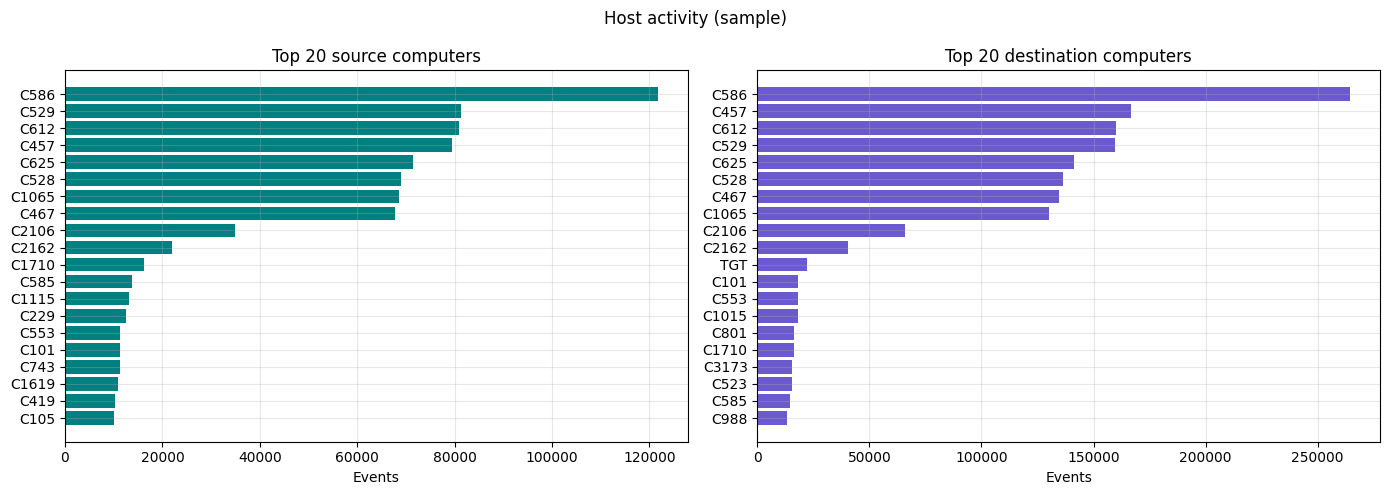

Top src:
src_computer
C586    121753
C529     81353
C612     80963
C457     79561
C625     71465
Name: count, dtype: int64
Top dst:
dst_computer
C586    264593
C457    166726
C612    160084
C529    159413
C625    141141
Name: count, dtype: int64
--- Section 6 summary: top src/dst hosts ---


In [10]:
top_src = auth["src_computer"].value_counts().head(20)
top_dst = auth["dst_computer"].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top_src.index[::-1], top_src.values[::-1], color="teal")
axes[0].set_title("Top 20 source computers")
axes[0].set_xlabel("Events")
axes[1].barh(top_dst.index[::-1], top_dst.values[::-1], color="slateblue")
axes[1].set_title("Top 20 destination computers")
axes[1].set_xlabel("Events")
plt.suptitle("Host activity (sample)")
savefig("06_top_src_dst_hosts.png")
plt.show()

print("Top src:")
print(top_src.head())
print("Top dst:")
print(top_dst.head())
print("--- Section 6 summary: top src/dst hosts ---")

## 7. Host degree proxy distributions

Per-host **out-count** (events as source) and **in-count** (events as destination); histograms on log scale; rank-frequency (CCDF-style).

Saved: ./figures/07_degree_histograms_log.png


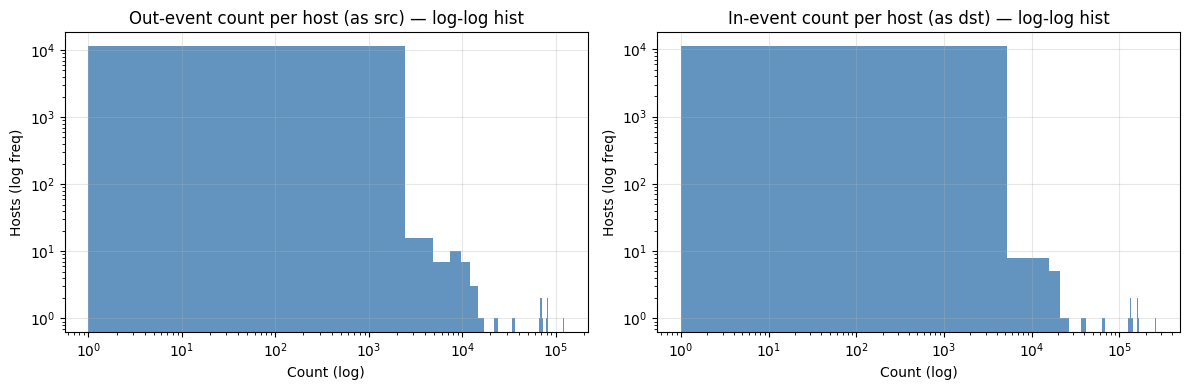

In [ ]:
out_deg = auth["src_computer"].value_counts()
in_deg = auth["dst_computer"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, series, title in [
    (axes[0], out_deg, "Out-event count per host (as src)"),
    (axes[1], in_deg, "In-event count per host (as dst)"),
]:
    x = series.values.astype(float)
    x = x[x > 0]
    ax.hist(x, bins=50, log=True, color="steelblue", alpha=0.85)
    ax.set_xscale("log")
    ax.set_title(title + " — log-log hist")
    ax.set_xlabel("Count (log)")
    ax.set_ylabel("Hosts (log freq)")
savefig("07_degree_histograms_log.png")
plt.show()

for name, series in [("out", out_deg), ("in", in_deg)]:
    x = np.sort(series.values.astype(float))[::-1]
    ranks = np.arange(1, len(x) + 1)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.loglog(ranks, x, color="darkblue", lw=1)
    ax.set_title(f"Rank-frequency (CCDF-style): {name}-event counts")
    ax.set_xlabel("Rank")
    ax.set_ylabel("Count")
    savefig(f"07_rank_freq_{name}.png")
    plt.show()

print("Out-degree stats:")
print(out_deg.describe())
print("In-degree stats:")
print(in_deg.describe())
print("--- Section 7 summary: degree distributions ---")

## 8. Unique counterpart counts per host

**Fan-out:** unique destination hosts per source; **fan-in:** unique source hosts per destination (on sample).

In [ ]:
fanout = auth.groupby("src_computer")["dst_computer"].nunique()
fanin = auth.groupby("dst_computer")["src_computer"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(fanout.values, bins=50, log=True, color="darkcyan", alpha=0.85)
axes[0].set_xscale("log")
axes[0].set_title("Unique dst per src (fan-out)")
axes[0].set_xlabel("Unique destinations")
axes[1].hist(fanin.values, bins=50, log=True, color="darkmagenta", alpha=0.85)
axes[1].set_xscale("log")
axes[1].set_title("Unique src per dst (fan-in)")
axes[1].set_xlabel("Unique sources")
savefig("08_fanout_fanin.png")
plt.show()

print("Fan-out describe:")
print(fanout.describe())
print("Fan-in describe:")
print(fanin.describe())
print("--- Section 8 summary: fan-out / fan-in ---")

## 9. Temporal burstiness at the host level

Inter-event times for a sample of active hosts and overall (src-side events for simplicity).

In [ ]:
n_hosts_sample = 500
active_hosts = auth["src_computer"].value_counts().head(n_hosts_sample).index
pieces = []
for h in active_hosts:
    t = auth.loc[auth["src_computer"] == h, "time"].sort_values().values
    if len(t) > 2:
        pieces.append(np.diff(t))
if pieces:
    iet_all = np.concatenate(pieces)
else:
    iet_all = np.array([])

fig, ax = plt.subplots(figsize=(10, 4))
if len(iet_all):
    ax.hist(np.maximum(iet_all, 1e-9), bins=80, log=True, color="gray", alpha=0.8)
    ax.set_xscale("log")
ax.set_title("Inter-event times (src events, top active hosts, log bins)")
ax.set_xlabel("Δt (seconds, log scale)")
ax.set_ylabel("Count")
savefig("09_inter_event_times_overall.png")
plt.show()

rep = list(active_hosts[:5])
fig, axes = plt.subplots(len(rep), 1, figsize=(10, 2 * len(rep)), sharex=True)
if len(rep) == 1:
    axes = [axes]
for ax, h in zip(axes, rep):
    t = auth.loc[auth["src_computer"] == h, "time"].sort_values().values
    if len(t) > 1:
        d = np.diff(t)
        ax.hist(np.clip(d, 1e-6, None), bins=40, log=True, color="steelblue", alpha=0.85)
        ax.set_xscale("log")
    ax.set_ylabel(str(h)[:12])
savefig("09_inter_event_per_host.png")
plt.show()

print("Inter-event deltas sampled:", len(iet_all))
print("--- Section 9 summary: burstiness / IET ---")

## 10. Rolling behavior features (6-hour window)

Trailing **6-hour** rolling metrics aligned with the planned model: auth count, success/failure, rolling unique out-neighbors (as src) and in-neighbors (as dst).

Shown for one **normal** host (high volume, not in red-team host list) and one host with **red-team** involvement if present in the sample.

In [ ]:
def rolling_host_panel(auth_df, host, window_sec=ROLLING_WINDOW_SEC):
    sub = auth_df[
        (auth_df["src_computer"] == host) | (auth_df["dst_computer"] == host)
    ].sort_values("time")
    if sub.empty:
        return pd.DataFrame()
    t = sub["time"].to_numpy()
    succ = sub["success"].astype(str).str.lower().eq("success").values
    w = float(window_sec)
    recs = []
    for i in range(len(sub)):
        ti = t[i]
        left = np.searchsorted(t, ti - w, side="left")
        sl = slice(left, i + 1)
        ch = sub.iloc[sl]
        recs.append(
            {
                "time": ti,
                "roll_auth": len(ch),
                "roll_success": int(succ[sl].sum()),
                "roll_failure": int((~succ[sl]).sum()),
                "roll_out_deg": ch.loc[ch["src_computer"] == host, "dst_computer"].nunique(),
                "roll_in_deg": ch.loc[ch["dst_computer"] == host, "src_computer"].nunique(),
            }
        )
    return pd.DataFrame(recs)


rt_hosts = set(redteam["src_computer"].dropna().astype(str)) | set(
    redteam["dst_computer"].dropna().astype(str)
)
normal_candidates = (
    auth.loc[~auth["src_computer"].astype(str).isin(rt_hosts), "src_computer"]
    .value_counts()
    .head(20)
    .index
)
normal_host = normal_candidates[0] if len(normal_candidates) else auth["src_computer"].mode().iloc[0]

auth_src = set(auth["src_computer"].astype(str))
auth_dst = set(auth["dst_computer"].astype(str))
red_on_sample = [h for h in rt_hosts if h in auth_src or h in auth_dst]
red_host = red_on_sample[0] if red_on_sample else str(normal_host)

print("Normal host (not in redteam host set):", normal_host)
print("Red-team involved host in sample:", red_host)

pn = rolling_host_panel(auth, normal_host)
pr = rolling_host_panel(auth, red_host)

fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
fields = [
    ("roll_auth", "Rolling auth count"),
    ("roll_success", "Rolling success count"),
    ("roll_failure", "Rolling failure count"),
    ("roll_out_deg", "Rolling unique dst (as src)"),
    ("roll_in_deg", "Rolling unique src (as dst)"),
]
for ax, (col, lab) in zip(axes, fields):
    if len(pn):
        ax.plot(pn["time"], pn[col], color="gray", alpha=0.8, label="normal host")
    if len(pr):
        ax.plot(pr["time"], pr[col], color="crimson", alpha=0.7, label="red-team host")
    ax.set_ylabel(lab)
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Time (s)")
plt.suptitle("6-hour rolling features (trailing window per event)")
savefig("10_rolling_features_normal_vs_red.png")
plt.show()
print("--- Section 10 summary: 6h rolling features ---")

## 11. Red-team host participation

Hosts appearing in `redteam` as source or destination; top by appearance count; baseline volume vs non-red-team hosts.

In [ ]:
rt_long = pd.concat(
    [
        redteam[["src_computer"]].rename(columns={"src_computer": "host"}),
        redteam[["dst_computer"]].rename(columns={"dst_computer": "host"}),
    ]
)
rt_long = rt_long.dropna()
rt_long["host"] = rt_long["host"].astype(str)
rt_appear = rt_long["host"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
top = rt_appear.head(25)
ax.barh(top.index[::-1], top.values[::-1], color="firebrick")
ax.set_title("Top hosts by red-team row appearances (src or dst)")
ax.set_xlabel("Count")
savefig("11_redteam_host_top.png")
plt.show()

auth_hosts = (
    set(auth["src_computer"].dropna().astype(str))
    | set(auth["dst_computer"].dropna().astype(str))
)
rt_host_set = set(rt_appear.index)
vol_rt = []
vol_bg = []
for h in auth_hosts:
    v = (auth["src_computer"] == h).sum() + (auth["dst_computer"] == h).sum()
    if h in rt_host_set:
        vol_rt.append(v)
    else:
        vol_bg.append(v)

fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(
    [vol_bg, vol_rt],
    labels=["Not in redteam host list", "Red-team-touched host"],
    vert=True,
)
ax.set_ylabel("Event count in sample (src+dst)")
ax.set_title("Baseline activity: red-team-involved vs other hosts")
savefig("11_volume_boxplot_rt_vs_bg.png")
plt.show()

print("Mean events (RT hosts):", float(np.mean(vol_rt)) if vol_rt else None)
print("Mean events (others):", float(np.mean(vol_bg)) if vol_bg else None)
print("--- Section 11 summary: red-team host participation ---")

## 12. Ego-network snapshot around a compromised host

One red-team **source computer**, interactions in a short window around its **first** red-team event; directed graph (matplotlib only).

In [ ]:
seed = str(redteam["src_computer"].dropna().iloc[0])
first_t = int(redteam.loc[redteam["src_computer"].astype(str) == seed, "time"].min())
window = 3600
win_lo, win_hi = first_t - window, first_t + window
ego = auth[
    (auth["time"] >= win_lo)
    & (auth["time"] <= win_hi)
    & ((auth["src_computer"] == seed) | (auth["dst_computer"] == seed))
].copy()

edges = ego.groupby(["src_computer", "dst_computer"]).size().reset_index(name="w")
nodes = list(set(ego["src_computer"].astype(str)) | set(ego["dst_computer"].astype(str)))
n = len(nodes)
pos = {}
for i, node in enumerate(nodes):
    ang = 2 * np.pi * i / max(n, 1)
    pos[node] = (np.cos(ang), np.sin(ang))

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect("equal")
for _, row in edges.iterrows():
    u, v = str(row["src_computer"]), str(row["dst_computer"])
    if u not in pos or v not in pos:
        continue
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    ax.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(arrowstyle="->", color="0.4", lw=0.6, alpha=0.7),
    )
for node, (x, y) in pos.items():
    col = "crimson" if node == seed else "lightblue"
    ax.scatter([x], [y], s=200, c=col, zorder=3, edgecolors="k")
    ax.text(x * 1.15, y * 1.15, node[:12], fontsize=7, ha="center")
ax.set_title(f"Ego network around {seed} (±{window}s around first RT event)")
ax.axis("off")
savefig("12_ego_network.png")
plt.show()

print("Ego edges in window:", len(edges), "| nodes:", len(nodes))
print("--- Section 12 summary: ego network ---")

## 13. Hour-of-day × day heatmap

**Hour-of-day** (0–23) vs **calendar day** for authentication counts; red-team-only heatmap.

In [ ]:
# `hour_of_day` (0..23) is the canonical "daily rhythm" axis — we keep
# `(time // 3600) % 24` here per the section's intent. The y-axis ("rows")
# uses elapsed days since sample start, computed in Section 1.
auth["hour_of_day"] = ((auth["time"] // 3600) % 24).astype(int)

day_hi = int(auth["elapsed_day_bin"].max())
all_days = np.arange(0, day_hi + 1)
pivot = (
    auth.groupby(["elapsed_day_bin", "hour_of_day"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=all_days, columns=range(24), fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 6))
# `extent` makes the y-pixel coordinates correspond exactly to elapsed days.
im = ax.imshow(
    pivot.values, aspect="auto", cmap="viridis", origin="lower",
    extent=[0, 24, 0, len(all_days)],
)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Elapsed day since sample start")
ax.set_title("Auth counts heatmap: elapsed day × hour-of-day (sample)")
plt.colorbar(im, ax=ax, label="Count")
savefig("13_heatmap_auth_day_hod.png")
plt.show()

# Red-team heatmap: restrict to the sample window first, then build the
# heatmap on the same elapsed-day axis as the auth heatmap above so the two
# are visually comparable.
t0 = int(auth["time"].min())
t_max = int(auth["time"].max())
rtp = redteam[(redteam["time"] >= t0) & (redteam["time"] <= t_max)].copy()
rtp["hour_of_day"] = ((rtp["time"] // 3600) % 24).astype(int)
rtp["elapsed_day_bin"] = np.floor((rtp["time"] - t0) / 86400.0).astype(np.int64)
rpivot = (
    rtp.groupby(["elapsed_day_bin", "hour_of_day"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=all_days, columns=range(24), fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(
    rpivot.values, aspect="auto", cmap="Reds", origin="lower",
    extent=[0, 24, 0, len(all_days)],
)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Elapsed day since sample start")
ax.set_title("Red-team events heatmap: elapsed day × hour-of-day (within sample window)")
plt.colorbar(im, ax=ax, label="Count")
savefig("13_heatmap_redteam_day_hod.png")
plt.show()
print("--- Section 13 summary: day × hour heatmaps ---")

## 14. Pre-malicious vs background comparison

For hosts in red-team data: summary stats in the **6 hours before** first involvement vs random **background** host-windows.

In [ ]:
rt_sub = redteam.dropna(subset=["time"])
first_times = {}
for _, row in rt_sub.iterrows():
    t = int(row["time"])
    for h in [row["src_computer"], row["dst_computer"]]:
        if pd.isna(h):
            continue
        h = str(h)
        first_times[h] = min(first_times.get(h, np.inf), t)

hosts_rt = [h for h, ft in first_times.items() if ft < np.inf]
pre_stats = []
win = 6 * 3600
for h in hosts_rt:
    ft = int(first_times[h])
    lo, hi = ft - win, ft
    sub = auth[(auth["time"] >= lo) & (auth["time"] < hi)]
    ev = sub[(sub["src_computer"] == h) | (sub["dst_computer"] == h)]
    if len(ev) == 0:
        continue
    fail = ~ev["success"].astype(str).str.lower().eq("success")
    out_e = ev[ev["src_computer"] == h]
    in_e = ev[ev["dst_computer"] == h]
    pre_stats.append(
        {
            "events": len(ev),
            "fail_ratio": float(fail.mean()),
            "uniq_dst": int(out_e["dst_computer"].nunique()) if len(out_e) else 0,
            "uniq_src": int(in_e["src_computer"].nunique()) if len(in_e) else 0,
            "out_deg": len(out_e),
            "in_deg": len(in_e),
        }
    )

pre_df = pd.DataFrame(pre_stats)

auth_hosts_list = list(auth_hosts)
t_min = int(auth["time"].min())
t_max = int(auth["time"].max()) - win
n_bg = min(500, max(50, len(auth_hosts_list) * 3))
bg_rows = []
for _ in range(n_bg):
    h = np.random.choice(auth_hosts_list)
    start = np.random.randint(t_min, max(t_min + 1, t_max))
    lo, hi = start, start + win
    sub = auth[(auth["time"] >= lo) & (auth["time"] < hi)]
    ev = sub[(sub["src_computer"] == h) | (sub["dst_computer"] == h)]
    if len(ev) == 0:
        continue
    fail = ~ev["success"].astype(str).str.lower().eq("success")
    out_e = ev[ev["src_computer"] == h]
    in_e = ev[ev["dst_computer"] == h]
    bg_rows.append(
        {
            "events": len(ev),
            "fail_ratio": float(fail.mean()),
            "uniq_dst": int(out_e["dst_computer"].nunique()) if len(out_e) else 0,
            "uniq_src": int(in_e["src_computer"].nunique()) if len(in_e) else 0,
            "out_deg": len(out_e),
            "in_deg": len(in_e),
        }
    )
bg_df = pd.DataFrame(bg_rows)

metrics = ["events", "fail_ratio", "uniq_dst", "out_deg", "in_deg"]
if len(pre_df) == 0 or len(bg_df) == 0:
    print("Skipping violin plots: insufficient pre-RT or background windows.")
else:
    fig, axes = plt.subplots(1, len(metrics), figsize=(16, 4))
    for ax, m in zip(axes, metrics):
        ax.violinplot(
            [pre_df[m].dropna().values, bg_df[m].dropna().values],
            positions=[1, 2],
            showmeans=True,
        )
        ax.set_xticks([1, 2])
        ax.set_xticklabels(["Pre-RT (6h)", "Background"])
        ax.set_title(m)
    plt.suptitle("Pre-malicious window vs background (sample)")
    savefig("14_pre_vs_bg_violin.png")
    plt.show()

print("Pre-RT windows:", len(pre_df), "| Background windows:", len(bg_df))
print("--- Section 14 summary: pre-RT vs background ---")

## 15. Forecast-label construction sanity check

**Label:** host is **positive** at decision time `t` if it appears in at least one red-team auth event in **(t, t + 30 min]**.

Decision times every **5 minutes**; plot positive host counts and imbalance over time.

In [ ]:
rta = auth_labeled[auth_labeled["is_redteam"]].copy()
rt_times_by_host = defaultdict(list)
for _, row in rta.iterrows():
    t = int(row["time"])
    for h in [row["src_computer"], row["dst_computer"]]:
        if pd.isna(h):
            continue
        rt_times_by_host[str(h)].append(t)

for h in rt_times_by_host:
    rt_times_by_host[h] = sorted(set(rt_times_by_host[h]))

t0 = int(auth["time"].min())
t1 = int(auth["time"].max())
step = DECISION_INTERVAL_SEC
horizon = FORECAST_HORIZON_SEC
grid = np.arange(t0, t1 - horizon, step, dtype=np.int64)

positives = []
all_hosts = sorted(auth_hosts)

for t in grid:
    pos = set()
    for h, times in rt_times_by_host.items():
        for te in times:
            if t < te <= t + horizon:
                pos.add(h)
                break
    positives.append(len(pos))

imbalance = [p / max(len(all_hosts), 1) for p in positives]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(grid, positives, color="darkred", lw=1)
axes[0].set_ylabel("Positive hosts")
axes[0].set_title("Positive hosts per decision time (label: RT auth in (t, t+30m])")
axes[1].plot(grid, imbalance, color="navy", lw=1)
axes[1].set_ylabel("Pos / all hosts")
axes[1].set_xlabel("Decision time (s)")
axes[1].set_title("Class imbalance proxy over time")
savefig("15_forecast_labels.png")
plt.show()

print("Decision grid points:", len(grid), "| Mean positives:", float(np.mean(positives)))
print("--- Section 15 summary: forecast label sanity check ---")

## 16. Feature correlation (sampled host-time windows)

Numeric features on random windows: event count, failure ratio, unique neighbors, mean inter-event time — **correlation heatmap**.

In [ ]:
n_win = 3000
rows = []
for _ in range(n_win):
    h = np.random.choice(auth_hosts_list)
    start = np.random.randint(t_min, max(t_min + 1, t_max))
    lo, hi = start, start + win
    sub = auth[(auth["time"] >= lo) & (auth["time"] < hi)]
    ev = sub[(sub["src_computer"] == h) | (sub["dst_computer"] == h)].sort_values("time")
    if len(ev) < 2:
        continue
    fail = ~ev["success"].astype(str).str.lower().eq("success")
    out_e = ev[ev["src_computer"] == h]
    in_e = ev[ev["dst_computer"] == h]
    ts = ev["time"].diff().dropna().mean()
    rows.append(
        {
            "n_events": len(ev),
            "fail_ratio": float(fail.mean()),
            "uniq_dst": int(out_e["dst_computer"].nunique()),
            "uniq_src": int(in_e["src_computer"].nunique()),
            "mean_iet": float(ts) if pd.notna(ts) else np.nan,
        }
    )

feat_df = pd.DataFrame(rows)
num = feat_df.select_dtypes(include=[np.number]).dropna()
if len(num) < 10 or num.shape[1] < 2:
    print("Not enough sampled windows for correlation heatmap; increase n_win or check data.")
else:
    corr = num.corr()
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr.columns)
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax)
    ax.set_title("Feature correlation (sampled windows)")
    savefig("16_feature_correlation.png")
    plt.show()

print(feat_df.describe())
print("--- Section 16 summary: feature correlation ---")

## What these plots suggest for a host-level temporal GNN

- **Temporal structure:** Hourly/daily volume and heatmaps show strong **enterprise rhythm**; **time-aware** models (and hour-of-day features) are justified. **Burstiness** (heavy-tailed inter-event times) supports **event streams** or **sequence models** over irregular timestamps, not only daily aggregates.
- **Graph:** Heavy-tailed **degree** and **fan-out/fan-in** motivate **GNNs on hosts** with edges from auth sessions; **hubs** are common—methods should handle **scale-free** statistics (normalization, sampling, or specialized layers).
- **Rolling window (6h):** Rolling counts, success/failure, and rolling unique neighbors align with a **6-hour history**; plots for normal vs red-team hosts illustrate **where** to inspect drift before incidents.
- **Forecast setup:** **5-minute** decision times with a **30-minute** horizon and sparse **positive hosts** per `t` match a **rare host-level** prediction task; the label sanity plot checks **sparsity** and **time-varying** prevalence.
- **Features vs redundancy:** Correlation heatmap highlights **which handcrafted scalars** move together (e.g., volume vs unique destinations)—useful before stacking features with graph embeddings.
- **Hosts as nodes:** Keep **users and auth metadata as edge/event attributes** or side features rather than expanding the node set, consistent with **lateral movement** on **machines**.

**Next steps:** Implement temporal snapshots every 5 minutes, build **host–host edges** from auth in the trailing 6 hours, attach **labels** from red-team auth matches in `(t, t+30m]`, and train a **temporal GNN** with class imbalance handling.